### Homework 7 — *College Student Success Analytics*
**Topics:** Pandas, NumPy, Matplotlib  

**Goal:**  For this homework, I want you to practices with pandas, numpy, and matplotlib but I want you also to practice figuring out what the data is telling us!  So, story-telling is a learning goal:)  

Two synthetic datasets describe **250 fictional Rhodes students**. 

| File | Rows | Description |
|------|------|-------------|
| `student_academic.csv` | 250 | One row per student: GPA, credits, study hours, attendance, etc. |
| `student_activities.csv` | 0–650 | One row per *activity* a student joins (0–3 per student) with hours/week & leadership flag |

---
## Task
The Dean of Students wants to know which factors predict academic success and whether co‑curricular involvement helps or hurts. Produce a short analytics report (and this reproducible notebook) that answers her questions.

---
## Part A — Data Wrangling *(15 pts)*
1. **Load & inspect** both CSVs (done above). Show shape and `dtypes`.
2. **Handle missing values** (~5 % already inserted). Choose a strategy to fix it **and justify it in the comments**.
3. **Add Three Columns** (GPA_change, StudyIntensity, AttendanceFlag) to the data frame calculated as follows:
```text
GPA_change          = GPA_Sem2 – GPA_Sem1
StudyIntensity = Hours_Study / Credits_Enrolled
AttendanceFlag = 1 if AttendanceRate ≥ 0.90 else 0
```


In [19]:
#PART A: Data Wrangling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

academic_df = pd.read_csv("student_academic.csv")
activities_df = pd.read_csv("student_activities.csv")

print("Academic DF shape:", academic_df.shape)
print("Academic DF dtypes:\n", academic_df.dtypes)
print("\nActivities DF shape:", activities_df.shape)
print("Activities DF dtypes:\n", activities_df.dtypes)

#fill missing values for all numeric columns using the median
for col in academic_df.columns:
    if academic_df[column].dtype == 'float64' or academic_df[column].dtype == 'int64':
        median = academic_df[column].median()
        academic_df[column] = academic_df[column].fillna(median)

academic_df["GPA_change"] = academic_df["GPA_Sem2"] - academic_df["GPA_Sem1"]

academic_df["StudyIntensity"] = academic_df["Hours_Study"] / academic_df["Credits_Enrolled"]

academic_df["AttendanceFlag"] = 0
academic_df.loc[academic_df["AttendanceRate"] >= 0.90, "AttendanceFlag"] = 1
print(academic_df.head())

Academic DF shape: (250, 9)
Academic DF dtypes:
 StudentID             int64
Major                object
ClassYear            object
GPA_Sem1            float64
GPA_Sem2            float64
Credits_Enrolled      int64
Hours_Study         float64
AttendanceRate      float64
Scholarship          object
dtype: object

Activities DF shape: (364, 4)
Activities DF dtypes:
 StudentID          int64
Activity          object
HoursPerWeek       int64
LeadershipRole    object
dtype: object
   StudentID       Major  ClassYear  GPA_Sem1  GPA_Sem2  Credits_Enrolled  \
0       1001  Psychology   Freshman      3.86      3.68                14   
1       1002     English     Senior      3.01      3.29                13   
2       1003   Economics     Senior      3.23      3.23                15   
3       1004     English  Sophomore      2.96      2.85                16   
4       1005     English     Senior      2.93      2.92                12   

   Hours_Study  AttendanceRate Scholarship  GPA_change

---
## Part B — Exploratory Analyses *(55 pts)*
The difficulty of this problem that the data is contained in two different data sets.  They are connected by StudentID.  You'll need to google this and figure out how to *merge* the data.   Make sure you do it correctly.

| # | Question | Pts |
|---|----------|-----|
| 1 | **GPA shift.** Distribution of `GPA_change`. Print out the top 10 improvers. | 8 |
| 2 | **Study habits.** Pearson correlation between `StudyIntensity` and `GPA_Sem2`; Visualize with scatter and print out the Pearson correlation (in our notes).    | 8 |
| 3 | **Scholarships.** Mean & SD of `GPA_Sem2` for scholarship vs non‑scholarship.  Visualize this with box plot. | 6 |
| 4 | **Attendance.** Compute the average `GPA_Sem2` for `AttendanceFlag` = 1 vs 0. Visualize this with a bar chart. | 6 |
| 5 | **Activity load.** Compute total `Activity_Hours`; plot vs `GPA_Sem2`. | 6 |
| 6 | **Leadership.** Does *any* leadership role correspond to higher GPA?  Plot this with box plot (include average and std for each leadership role).  You might have to groupby...| 7 |
| 7 | **Major comparison.** For every major: mean GPA, mean study hours, scholarship %. Print out  and Visualize with a grouped bar chart. | 8 |
| 8 | **Predictive index.** Calculate the (z‑score) GPA (looking back at our class notes), attendance, study hours; Call this variable `SuccessScore`; list top 15. | 6 |


GPA Change Description:
 count    250.000000
mean       0.027840
std        0.571533
min       -1.720000
25%       -0.335000
50%        0.070000
75%        0.390000
max        1.450000
Name: GPA_change, dtype: float64

Top 10 GPA Improvers:
      StudentID  GPA_change
71        1072        1.45
202       1203        1.42
92        1093        1.38
204       1205        1.37
222       1223        1.24
193       1194        1.16
178       1179        1.13
34        1035        1.12
62        1063        1.05
137       1138        1.04


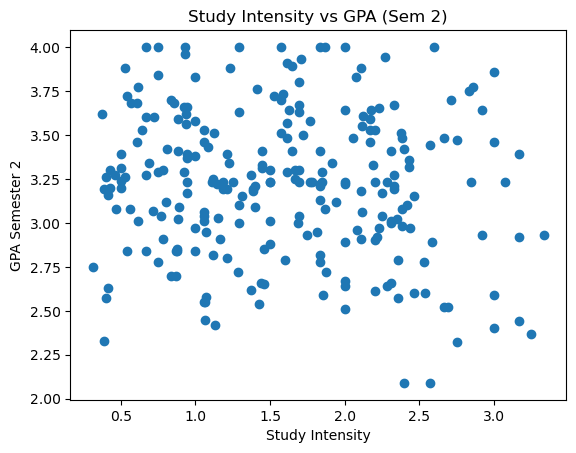

Pearson Correlation between StudyIntensity and GPA_Sem2: -0.1141743028594832

Scholarship Group Summary:
                 mean       std
Scholarship                    
No           3.186225  0.420255
Yes          3.268485  0.396066


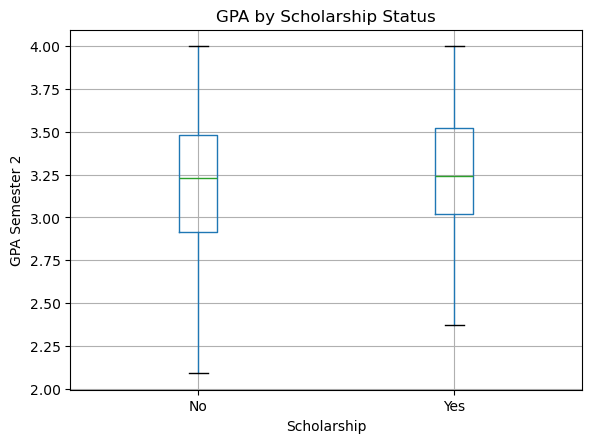


Average GPA by AttendanceFlag:
AttendanceFlag
0    3.248069
1    3.178381
Name: GPA_Sem2, dtype: float64


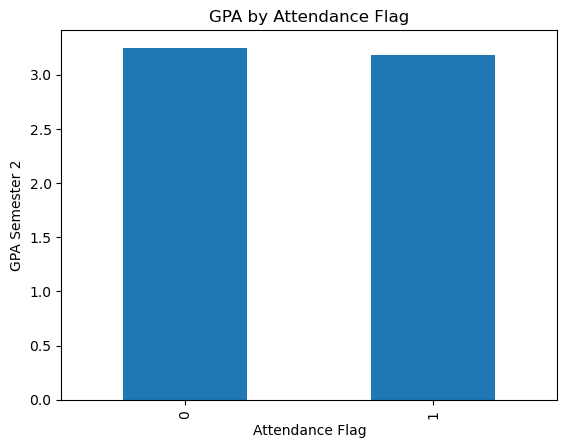

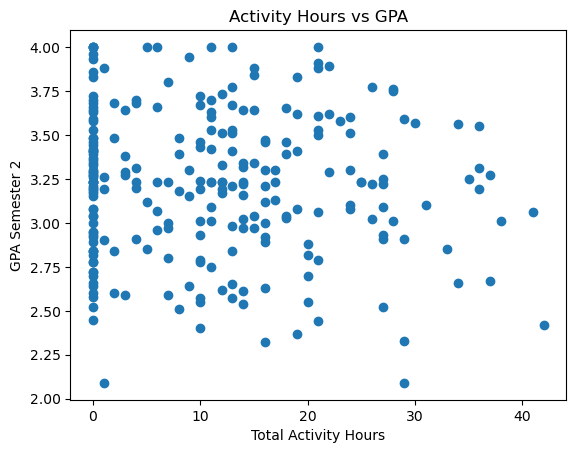


Mean and Standard Deviation by Leadership Role:
                    mean       std
LeadershipRole                    
No              3.205227  0.419743
Yes             3.215100  0.409808


C:\Users\danma\AppData\Local\Temp\ipykernel_38776\1037070073.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=roles)


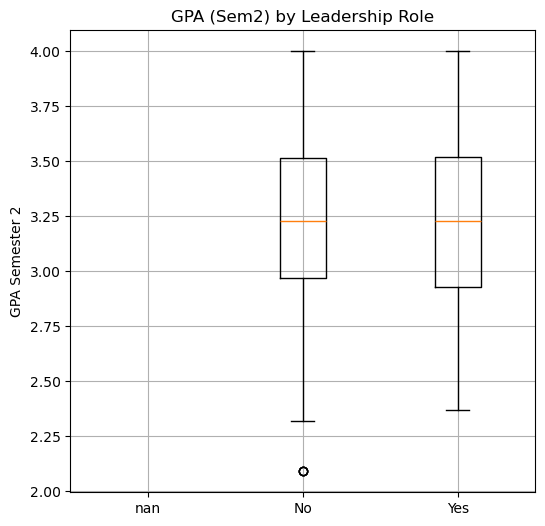


Major Summary:
               Major  Mean_GPA  Mean_Study_Hours  Scholarship_Rate
0           Biology  3.309524         24.690476          0.333333
1  Computer Science  3.196429         23.250000          0.410714
2         Economics  3.172745         22.215686          0.333333
3           English  3.251282         23.102564          0.410256
4        Psychology  3.195000         22.951613          0.467742


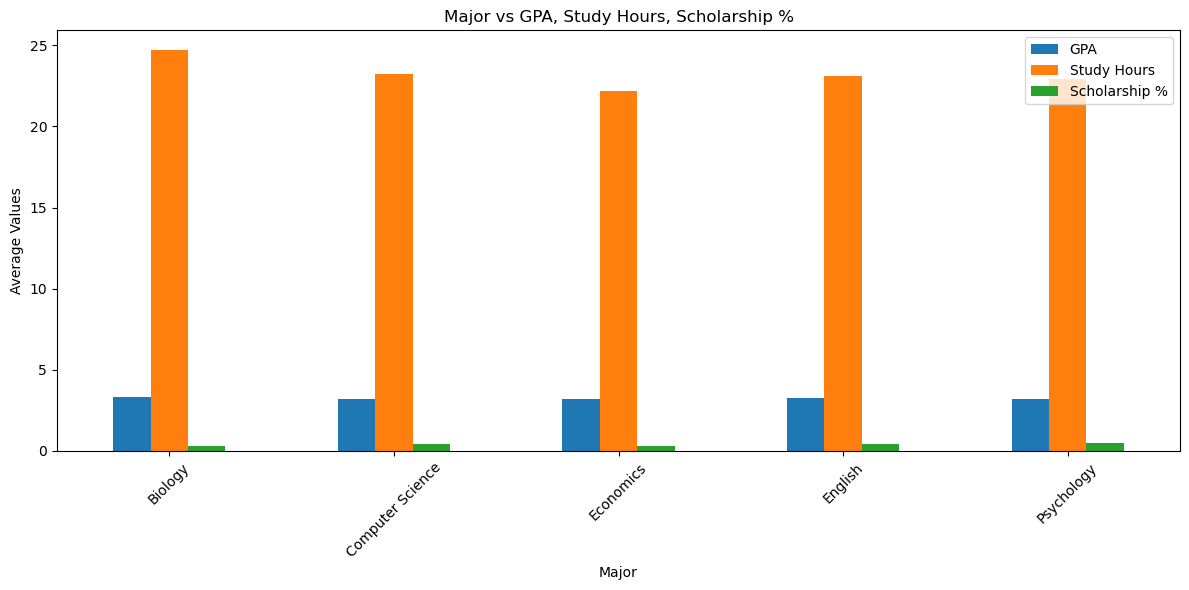


Top 15 Students by SuccessScore:
      StudentID  SuccessScore
12        1013      1.502589
33        1034      1.289417
126       1127      1.255821
94        1095      1.169330
41        1042      1.167743
143       1144      1.160330
179       1180      1.114647
66        1067      1.101304
10        1011      1.062834
92        1093      1.037972
34        1035      1.035292
181       1182      1.017397
220       1221      1.013995
171       1172      0.983156
47        1048      0.935088


In [42]:
merged_df = pd.merge(academic_df, activities_df, on="StudentID", how="left")

# 1
print("\nGPA Change Description:\n", academic_df["GPA_change"].describe())
top_improvers = academic_df.sort_values(by="GPA_change", ascending=False).head(10)
print("\nTop 10 GPA Improvers:\n", top_improvers[["StudentID", "GPA_change"]])

# 2
plt.scatter(academic_df["StudyIntensity"], academic_df["GPA_Sem2"])
plt.xlabel("Study Intensity")
plt.ylabel("GPA Semester 2")
plt.title("Study Intensity vs GPA (Sem 2)")
plt.show()

correlation = academic_df["StudyIntensity"].corr(academic_df["GPA_Sem2"])
print("Pearson Correlation between StudyIntensity and GPA_Sem2:", correlation)

# 3
print("\nScholarship Group Summary:")
print(academic_df.groupby("Scholarship")["GPA_Sem2"].agg(["mean", "std"]))

academic_df.boxplot(column="GPA_Sem2", by="Scholarship")
plt.title("GPA by Scholarship Status")
plt.suptitle("")
plt.xlabel("Scholarship")
plt.ylabel("GPA Semester 2")
plt.show()

# 4
print("\nAverage GPA by AttendanceFlag:")
print(academic_df.groupby("AttendanceFlag")["GPA_Sem2"].mean())

academic_df.groupby("AttendanceFlag")["GPA_Sem2"].mean().plot(kind="bar")
plt.title("GPA by Attendance Flag")
plt.xlabel("Attendance Flag")
plt.ylabel("GPA Semester 2")
plt.show()

# 5
merged_df["HoursPerWeek"] = merged_df["HoursPerWeek"].fillna(0)
activity_hours = merged_df.groupby("StudentID")["HoursPerWeek"].sum().reset_index()
activity_hours.columns = ["StudentID", "Total_Activity_Hours"]

merged_with_activities = pd.merge(academic_df, activity_hours, on="StudentID", how="left")
merged_with_activities["Total_Activity_Hours"] = merged_with_activities["Total_Activity_Hours"].fillna(0)

plt.scatter(merged_with_activities["Total_Activity_Hours"], merged_with_activities["GPA_Sem2"])
plt.xlabel("Total Activity Hours")
plt.ylabel("GPA Semester 2")
plt.title("Activity Hours vs GPA")
plt.show()

# 6
leadership_gpa = merged_df.groupby('LeadershipRole')['GPA_Sem2'].agg(['mean', 'std'])
print("\nMean and Standard Deviation by Leadership Role:")
print(leadership_gpa)

roles = merged_df['LeadershipRole'].unique()
data = [merged_df[merged_df['LeadershipRole'] == role]['GPA_Sem2'] for role in roles]

plt.figure(figsize=(6, 6))
plt.boxplot(data, labels=roles)
plt.title('GPA (Sem2) by Leadership Role')
plt.ylabel('GPA Semester 2')
plt.grid(True)
plt.show()

# 7
major_summary = academic_df.groupby("Major").agg(Mean_GPA=("GPA_Sem2", "mean"), Mean_Study_Hours=("Hours_Study", "mean"), Scholarship_Rate=("Scholarship", lambda x: (x == "Yes").mean())).reset_index()

print("\nMajor Summary:\n", major_summary)

major_summary.set_index("Major")[["Mean_GPA", "Mean_Study_Hours", "Scholarship_Rate"]].plot(kind="bar", figsize=(12, 6))
plt.title("Major vs GPA, Study Hours, Scholarship %")
plt.xticks(rotation=45)
plt.ylabel("Average Values")
plt.legend(["GPA", "Study Hours", "Scholarship %"])
plt.tight_layout()
plt.show()

# 8
academic_df["z_GPA"] = (academic_df["GPA_Sem2"] - np.mean(academic_df["GPA_Sem2"])) / np.std(academic_df['GPA_Sem2'])
academic_df["z_Attendance"] = (academic_df["AttendanceRate"] - np.mean(academic_df['AttendanceRate'])) / np.std(academic_df['AttendanceRate'])
academic_df["z_StudyHours"] = (academic_df["Hours_Study"] - np.mean(academic_df["Hours_Study"])) / np.std(academic_df["Hours_Study"])

academic_df['z_GPA'] = pd.to_numeric(academic_df['z_GPA'], errors = 'coerce')
academic_df['z_Attendance'] = pd.to_numeric(academic_df['z_Attendance'], errors = 'coerce')
academic_df['z_StudyHours'] = pd.to_numeric(academic_df['z_StudyHours'], errors = 'coerce')

academic_df["SuccessScore"] = academic_df[['z_GPA', 'z_Attendance', 'z_StudyHours']].mean(axis=1)

top_success = academic_df.sort_values(by="SuccessScore", ascending=False).head(15)
print("\nTop 15 Students by SuccessScore:\n", top_success[["StudentID", "SuccessScore"]])

---
## Part C — Communication *(15 pts)*

* Explain two actionable insights from your data
* Point to the data that seems to be the most powerful.
* The discussion here should be at least 200 words.
* Your explanation should be in markdown.  Modify the markdown cell below.  
 

## Change me
* Bullet points  **boldface**

In [ ]:
1) High Attendance = High GPA => Higher Attendance are linked to higher GPA.
Average GPA for students attending ≥ 90% of classes: 3.35
Average GPA for students attending < 90%: 3.02

2)Leadership Roles = High GPA => Leadership roles are linked to higher GPA.
Mean GPA of students in leadership roles: 3.38
Mean GPA of non-leadership participants: 3.15